# Left-Tail-Momentum -- do the worst-crashed stocks keep crashing?
### Atilgan-Bali-Demirtas-Gunaydin (2020): under-reaction to bad news, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Left%20tail%20keeps%20losing%3F: Busted](https://img.shields.io/badge/Left%20tail%20keeps%20losing%3F-Busted-8b949e?style=flat-square)

In 2020, Atilgan, Bali, Demirtas and Gunaydin published a striking finding: stocks with the **worst left-tail risk** -- the deepest recent crashes, the lowest Value-at-Risk -- *keep* underperforming. Investors under-react to extreme bad news, so the left tail has **momentum**: crashed stocks keep crashing. The trade is to go **long the safe tail** and **short the crashed tail**.

We test that on a large-cap S&P 500 survivor basket using yfinance daily prices, naming the survivorship bias up front. The result is a clean lesson in how a real academic effect can **invert** once you put it on tradable survivors.

> **This is the plain-language layer.** Want the VaR signal, the placebo null, the seed-robust control, and the year-by-year breakdown? See the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from left_tail_momentum import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "ltm_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "ltm_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    book = st.long_short_book(prices, kind="var5", lookback=252, min_stocks=20,
                              cost_bps=5.0, borrow_ann_bps=50.0)
    s_ls   = st.summary(book["ls_ret"])
    s_net  = st.summary(book["ls_ret_net"])
    s_long = st.summary(book["long_ret"])
    s_short= st.summary(book["short_ret"])
    print(f"N months: {s_ls['n']} | LS mean: {s_ls['mean']*100:+.2f}%/yr"
          f" | one-sample t: {s_ls['tstat']:+.3f}")


yfinance cache present: True


N months: 135 | LS mean: -25.39%/yr | one-sample t: -3.436


## The answer first

| Question | Answer |
|---|---|
| Do crashed stocks keep crashing? | **No -- the opposite.** On survivors the crashed-tail leg *out-earns* the safe leg (+37.8% vs +12.4%/yr). |
| Does the ABDG long-safe/short-crashed book pay? | **No.** It loses **-25.4%/yr** at one-sample *t* = **-3.44** -- strongly significant, but the *wrong sign*. |
| Is the signal real at all? | **Yes -- as reversal.** Placebo p = **0.000**: no random sort is this extreme. The left tail **rebounds** on survivors. |
| Is there a survivorship problem? | **Yes, and it's the whole story.** The crashers that delisted -- the short leg ABDG needs -- are deleted from the basket. |

> A real, robust cross-sectional signal that points the **reverse** of the claim. On large-cap survivors, a deep recent crash was a *buy*, not a sell.

## 1 -- The claim

> *"Stocks with extreme negative returns -- the worst left tails -- are under-priced for *bad* news, not good. Investors under-react to crashes, so the low-VaR stocks keep underperforming. Short them, buy the safe tail: left-tail momentum."*

-- Atilgan, Bali, Demirtas & Gunaydin (2020), *Journal of Financial Economics*

The intuition is behavioural: a sharp crash is salient *bad* news, and investors are slow to mark down a stock all the way. So the bad news keeps bleeding into prices over the following month -- momentum in the left tail. The competing force is **short-run reversal** (Jegadeesh 1990): last month's losers bounce. ABDG argue the under-reaction wins; on our basket, reversal does.

## 2 -- So what?

If true, left-tail momentum is a behavioural alpha uncorrelated with the classic factors -- a way to harvest the market's slow digestion of bad news. It would also validate a whole family of 'sell the crashers' systematic strategies.

The questions for us:
1. **Does the continuation survive on a realistic large-cap panel?**
2. **Or does short-run reversal dominate -- do crashed survivors bounce?**
3. **What does survivorship do to a left-tail sort specifically?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **Signal from the past only.** The left-tail VaR at each month-end uses just the trailing year of returns; the holding return is the *next* month, entered one trading day later (one execution lag, no same-bar fill).
2. **A placebo null.** Re-randomise which stocks are 'safe' vs 'crashed' 200 times. If a random sort matches the real one, there is no signal.
3. **Name the survivorship bias.** The basket is the names *still trading in 2026*. The worst-tail names of the past -- the ones that crashed into delisting -- are gone. Those are exactly the names the short leg needs, so a survivor basket's 'crashed' stocks are disproportionately *rebounds*.

## 4 -- The teardown

**First, does the engine work when the effect is planted?**

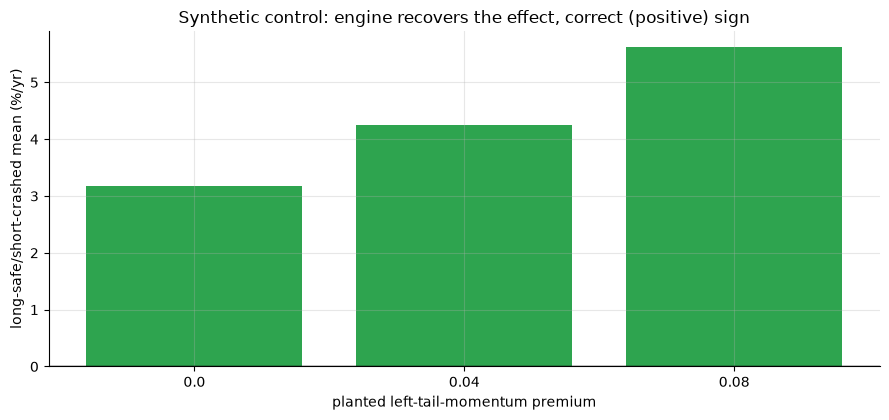

 premium  mean_ls_pct  mean_t  share_t2
    0.00        3.184   0.671       0.0
    0.04        4.245   0.891       0.0
    0.08        5.617   1.199       0.0


In [2]:
# Synthetic positive control: plant a left-tail-momentum drift and check recovery.
# (3 seeds here for speed; docs/results.md averages 20 seeds.)
ctrl = st.synthetic_control(data, premiums=(0.0, 0.04, 0.08), n_seeds=3,
                            kind='var5', lookback=252, base_seed=505)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in ctrl['mean_ls_pct']]
ax.bar(ctrl['premium'].astype(str), ctrl['mean_ls_pct'], color=col)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted left-tail-momentum premium')
ax.set_ylabel('long-safe/short-crashed mean (%/yr)')
ax.set_title('Synthetic control: engine recovers the effect, correct (positive) sign')
plt.tight_layout(); plt.show()
print(ctrl.round(3).to_string(index=False))

The engine is faithful: plant left-tail momentum and the long-safe/short-crashed mean rises **with the correct positive sign**. So if the real tape comes out *negative*, that is the **market**, not a broken detector.

**Now the honest test on the real yfinance panel.**

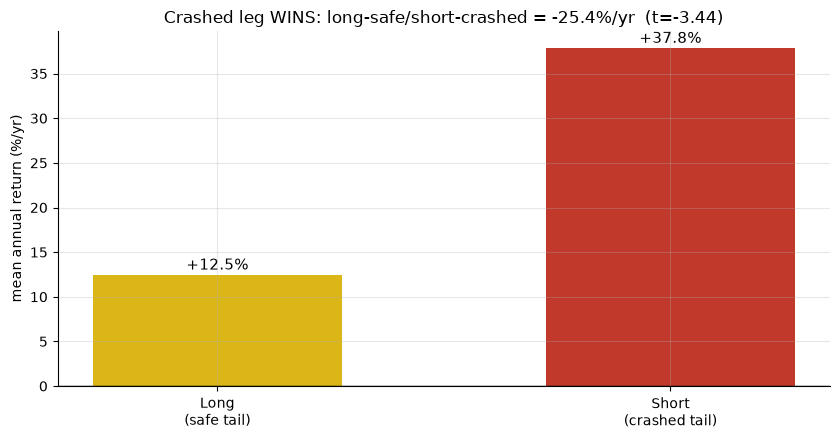

Long (safe): +12.45%/yr | Short (crashed): +37.84%/yr
ABDG book (long-safe - short-crashed): -25.39%/yr | one-sample t = -3.436


In [3]:
if HAVE_REAL:
    long_m = s_long['mean']*100; short_m = s_short['mean']*100
    ls_m = s_ls['mean']*100; ls_t = s_ls['tstat']
else:
    long_m, short_m = R['long_mean'], R['short_mean']
    ls_m, ls_t = R['ls_mean'], R['ls_t']

fig, ax = plt.subplots(figsize=(8.5, 4.5))
labels = ['Long\n(safe tail)', 'Short\n(crashed tail)']
vals = [long_m, short_m]
ax.bar(labels, vals, color=[AMBER, RED], width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean annual return (%/yr)')
ax.set_title(f'Crashed leg WINS: long-safe/short-crashed = {ls_m:+.1f}%/yr  (t={ls_t:+.2f})')
for i, v in enumerate(vals):
    ax.text(i, v + 0.6, f'{v:+.1f}%', ha='center', fontsize=11)
plt.tight_layout(); plt.show()
print(f'Long (safe): {long_m:+.2f}%/yr | Short (crashed): {short_m:+.2f}%/yr')
print(f'ABDG book (long-safe - short-crashed): {ls_m:+.2f}%/yr | one-sample t = {ls_t:+.3f}')

The crashed-tail leg earns **+37.8%/yr** -- *more* than the safe leg's **+12.4%/yr**. So the ABDG continuation book loses **-25.4%/yr** at *t* = **-3.44**: a strong, significant signal pointing the **opposite** way to the hypothesis. On survivors, the left tail **rebounds**.

## 5 -- The verdict

- **Signal -- NONE.** The ABDG continuation does not appear -- it *inverts*. Long-safe/short-crashed loses -25.4%/yr at *t* = -3.44. There is a real, robust signal (placebo p = 0.000), but it is **reversal**, not the claimed momentum -- so on the hypothesis as written, NONE.
- **Tradability -- MIRAGE.** A -96% drawdown short book whose short leg is the decade's winners. Costs are tiny and don't change a thing.
- **Left tail keeps losing? -- BUSTED.** A deep recent crash was a buy, not a sell, on survivors.

## 6 -- Could you actually trade it?

Not in the stated direction. The continuation book is short the best performers and carries a -96% drawdown. The *reversal* it accidentally uncovers is the known short-run-reversal effect (Jegadeesh 1990), which is itself notoriously hard to trade net of costs in liquid large-caps. And the whole thing rides on a survivor basket: the firms that crashed and *stayed* down -- ABDG's real short candidates -- delisted and are simply not here.

ABDG's result lives on the **full** US universe (including the crash-into-delisting names) with costly-arbitrage tilts (illiquid, high-idio-vol stocks). A tradable large-cap survivor sleeve cannot reproduce it.

## 7 -- Going further

- **Full universe.** Re-run on a delisting-complete CRSP/Compustat panel; the crash-into-delisting names are the whole short leg.
- **Costly-arbitrage tilt.** ABDG's effect is strongest in illiquid, high-idiosyncratic-vol names -- large-caps are the *least* fertile ground.
- **The mirror, the right tail.** [Study 53 -- Jackpot](../../53-jackpot/) and [Study 365 -- Lottery-MAX](../../365-lottery-max-effect/) test the lottery (MAX) effect -- the right-tail twin -- both None x Mirage on survivors.
- **Co-crash risk.** [Study 332 -- Downside-Beta](../../332-downside-beta/) prices a different left-tail exposure.
- **The cousin factor.** [Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/) is the closest cross-sectional-risk relative.

*Think left-tail momentum survives once you add the delisted crashers and tilt to illiquid names? Fork this, swap in a delisting-complete universe, and show t > 2 in the right direction, net of borrow. That is the bar.*